In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 27

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 20)                860       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 27)                297       
                                                                 
Total params: 1,367
Trainable params: 1,367
Non-trainable params: 0
_________________________________________________________________


In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


2022-12-04 04:21:38.611205: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1/1 [==============================] - ETA: 0s - loss: 3.3444 - accuracy: 0.0000e+00
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 386ms/step - loss: 3.3444 - accuracy: 0.0000e+00 - val_loss: 3.2973 - val_accuracy: 0.0000e+00
Epoch 2/1000
1/1 [==============================] - ETA: 0s - loss: 3.3535 - accuracy: 0.0139
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 17ms/step - loss: 3.3535 - accuracy: 0.0139 - val_loss: 3.2729 - val_accuracy: 0.0000e+00
Epoch 3/1000
1/1 [==============================] - ETA: 0s - loss: 3.2944 - accuracy: 0.0000e+00
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 3.2944 - accuracy: 0.0000e+00 - val_loss: 3.2490 - val_accuracy: 0.0000e+00
Epoch 4/1000
1/1 [==============================] - ETA: 0s - loss: 3.3193 - accuracy: 0.0

1/1 [==============================] - ETA: 0s - loss: 2.7877 - accuracy: 0.5278
Epoch 28: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 2.7877 - accuracy: 0.5278 - val_loss: 2.7395 - val_accuracy: 1.0000
Epoch 29/1000
1/1 [==============================] - ETA: 0s - loss: 2.7168 - accuracy: 0.5417
Epoch 29: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 19ms/step - loss: 2.7168 - accuracy: 0.5417 - val_loss: 2.7119 - val_accuracy: 1.0000
Epoch 30/1000
1/1 [==============================] - ETA: 0s - loss: 2.7039 - accuracy: 0.6389
Epoch 30: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 2.7039 - accuracy: 0.6389 - val_loss: 2.6819 - val_accuracy: 1.0000
Epoch 31/1000
1/1 [==============================] - ETA: 0s - loss: 2.6528 - accuracy: 0.7778
Epoch 31: saving mo

1/1 [==============================] - 0s 18ms/step - loss: 1.6495 - accuracy: 0.9722 - val_loss: 1.5771 - val_accuracy: 1.0000
Epoch 56/1000
1/1 [==============================] - ETA: 0s - loss: 1.5607 - accuracy: 0.9861
Epoch 56: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 1.5607 - accuracy: 0.9861 - val_loss: 1.5179 - val_accuracy: 1.0000
Epoch 57/1000
1/1 [==============================] - ETA: 0s - loss: 1.5556 - accuracy: 1.0000
Epoch 57: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 17ms/step - loss: 1.5556 - accuracy: 1.0000 - val_loss: 1.4583 - val_accuracy: 1.0000
Epoch 58/1000
1/1 [==============================] - ETA: 0s - loss: 1.3809 - accuracy: 1.0000
Epoch 58: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 17ms/step - loss: 1.3809 - accuracy: 1.0000 - val_loss: 1.

...

1/1 [==============================] - ETA: 0s - loss: 1.3773e-04 - accuracy: 1.0000
Epoch 697: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 1.3773e-04 - accuracy: 1.0000 - val_loss: 4.0233e-07 - val_accuracy: 1.0000
Epoch 698/1000
1/1 [==============================] - ETA: 0s - loss: 2.5221e-04 - accuracy: 1.0000
Epoch 698: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 2.5221e-04 - accuracy: 1.0000 - val_loss: 4.0233e-07 - val_accuracy: 1.0000
Epoch 699/1000
1/1 [==============================] - ETA: 0s - loss: 1.9861e-04 - accuracy: 1.0000
Epoch 699: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 1.9861e-04 - accuracy: 1.0000 - val_loss: 3.9736e-07 - val_accuracy: 1.0000
Epoch 700/1000
1/1 [==============================] - ETA: 0s - loss: 2.4

1/1 [==============================] - ETA: 0s - loss: 1.1853e-04 - accuracy: 1.0000
Epoch 723: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 1.1853e-04 - accuracy: 1.0000 - val_loss: 2.8312e-07 - val_accuracy: 1.0000
Epoch 724/1000
1/1 [==============================] - ETA: 0s - loss: 3.8598e-04 - accuracy: 1.0000
Epoch 724: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 17ms/step - loss: 3.8598e-04 - accuracy: 1.0000 - val_loss: 2.7319e-07 - val_accuracy: 1.0000
Epoch 725/1000
1/1 [==============================] - ETA: 0s - loss: 4.9327e-04 - accuracy: 1.0000
Epoch 725: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 4.9327e-04 - accuracy: 1.0000 - val_loss: 2.6822e-07 - val_accuracy: 1.0000
Epoch 726/1000
1/1 [==============================] - ETA: 0s - loss: 8.7

1/1 [==============================] - ETA: 0s - loss: 6.0809e-05 - accuracy: 1.0000
Epoch 749: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 6.0809e-05 - accuracy: 1.0000 - val_loss: 1.8378e-07 - val_accuracy: 1.0000
Epoch 750/1000
1/1 [==============================] - ETA: 0s - loss: 0.0039 - accuracy: 1.0000
Epoch 750: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 19ms/step - loss: 0.0039 - accuracy: 1.0000 - val_loss: 1.7385e-07 - val_accuracy: 1.0000
Epoch 751/1000
1/1 [==============================] - ETA: 0s - loss: 7.8762e-04 - accuracy: 1.0000
Epoch 751: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 17ms/step - loss: 7.8762e-04 - accuracy: 1.0000 - val_loss: 1.7385e-07 - val_accuracy: 1.0000
Epoch 752/1000
1/1 [==============================] - ETA: 0s - loss: 2.0358e-04 

1/1 [==============================] - ETA: 0s - loss: 3.9176e-04 - accuracy: 1.0000
Epoch 775: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 3.9176e-04 - accuracy: 1.0000 - val_loss: 1.5895e-07 - val_accuracy: 1.0000
Epoch 776/1000
1/1 [==============================] - ETA: 0s - loss: 6.2083e-04 - accuracy: 1.0000
Epoch 776: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 19ms/step - loss: 6.2083e-04 - accuracy: 1.0000 - val_loss: 1.5895e-07 - val_accuracy: 1.0000
Epoch 777/1000
1/1 [==============================] - ETA: 0s - loss: 4.1247e-05 - accuracy: 1.0000
Epoch 777: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 19ms/step - loss: 4.1247e-05 - accuracy: 1.0000 - val_loss: 1.5895e-07 - val_accuracy: 1.0000
Epoch 778/1000
1/1 [==============================] - ETA: 0s - loss: 5.3

1/1 [==============================] - ETA: 0s - loss: 0.0012 - accuracy: 1.0000
Epoch 801: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 0.0012 - accuracy: 1.0000 - val_loss: 1.3908e-07 - val_accuracy: 1.0000
Epoch 802/1000
1/1 [==============================] - ETA: 0s - loss: 5.9815e-05 - accuracy: 1.0000
Epoch 802: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 5.9815e-05 - accuracy: 1.0000 - val_loss: 1.3908e-07 - val_accuracy: 1.0000
Epoch 803/1000
1/1 [==============================] - ETA: 0s - loss: 2.3171e-04 - accuracy: 1.0000
Epoch 803: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
1/1 [==============================] - 0s 18ms/step - loss: 2.3171e-04 - accuracy: 1.0000 - val_loss: 1.3908e-07 - val_accuracy: 1.0000
Epoch 804/1000
1/1 [==============================] - ETA: 0s - loss: 0.0013 - ac

In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

1/1 [==============================] - 0s 10ms/step - loss: 1.2914e-07 - accuracy: 1.0000


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 41ms/step
[1.0000000e+00 5.6607019e-10 1.5592561e-10 1.5674621e-10 9.3991731e-11
 2.9366620e-09 1.6579976e-09 1.8578861e-09 5.7383790e-12 1.1378945e-10
 1.3276142e-09 9.8086943e-09 8.0128664e-12 5.3987317e-09 6.4182180e-11
 7.5492217e-11 2.7891929e-09 5.9904472e-09 9.5576158e-10 3.0899911e-11
 1.9821722e-10 2.5386663e-11 3.3580381e-08 3.6609143e-10 1.5369526e-08
 3.8496699e-09 1.5857815e-10]
0


# Confusion matrix

1/1 [==============================] - 0s 8ms/step


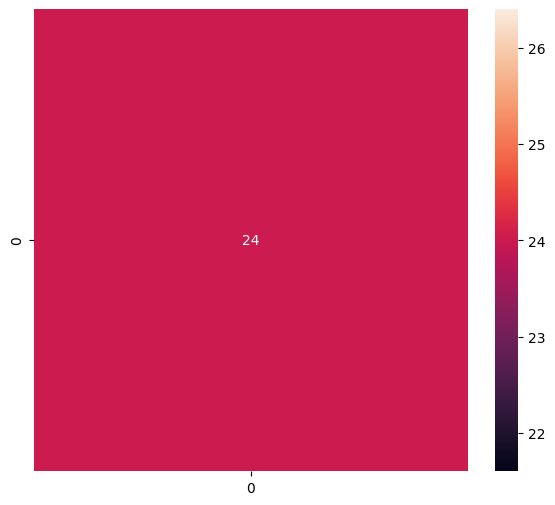

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpugzfgr2b/assets


2022-12-04 04:22:11.156986: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2022-12-04 04:22:11.157002: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2022-12-04 04:22:11.157628: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpugzfgr2b
2022-12-04 04:22:11.158409: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2022-12-04 04:22:11.158415: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpugzfgr2b
2022-12-04 04:22:11.160710: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:354] MLIR V1 optimization pass is not enabled
2022-12-04 04:22:11.161457: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2022-12-04 04:22:11.190989: I tensorflow/cc/saved_model/loader.

7556

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 376 µs, sys: 221 µs, total: 597 µs
Wall time: 401 µs


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.0000000e+00 5.6607019e-10 1.5592561e-10 1.5674621e-10 9.3991731e-11
 2.9366620e-09 1.6579976e-09 1.8578825e-09 5.7383681e-12 1.1378945e-10
 1.3276142e-09 9.8086943e-09 8.0128664e-12 5.3987317e-09 6.4182180e-11
 7.5492078e-11 2.7891929e-09 5.9904357e-09 9.5576158e-10 3.0899911e-11
 1.9821683e-10 2.5386663e-11 3.3580381e-08 3.6609143e-10 1.5369526e-08
 3.8496699e-09 1.5857815e-10]
0
